

# Credit Card Default (Taiwan) -- Role 3: Modeling & Evaluation

This notebook builds on `credit_default.ipynb` (Role 1) and `eda_role2.ipynb` (Role 2).
It implements and compares four classifiers on the preprocessed dataset.

## Imports

In [16]:
# Basic data handling & plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')      # ignore warnings to keep output clean

# ----------------------------


# Preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ----------------------------


# Model
from sklearn.linear_model import LogisticRegression

# ----------------------------


# Evaluation & validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# ----------------------------


# Plot styling
sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE = ['#2ecc71', '#e74c3c']
RANDOM_STATE = 42

print('ready.')

ready.


---
## 1. Data Loading & Preprocessing

Replicating Role 1's pipeline exactly so this notebook runs end-to-end on its own.

In [17]:
# Try loading dataset from possible paths
DATASET_CANDIDATES = [
    'dataset/default of credit card clients.xls',
    '../dataset/default of credit card clients.xls'
]

df = None
for candidate in DATASET_CANDIDATES:
    try:
        df = pd.read_excel(candidate, header=1)
        print(f'Loaded from: {candidate}')
        break
    except FileNotFoundError:
        continue

# If dataset not found stop execution
if df is None:
    raise FileNotFoundError('Dataset not found. Check that dataset/ folder is at the project root.')

# ----------------------------


# Basic dataset info
TARGET_COL = 'default payment next month'
print(f'Shape: {df.shape}')
print(f'Default rate: {df[TARGET_COL].mean()*100:.2f}%')

Loaded from: ../dataset/default of credit card clients.xls
Shape: (30000, 25)
Default rate: 22.12%


In [18]:
# Split features and target
work_df = df.drop(columns=['ID'])
X = work_df.drop(columns=[TARGET_COL])
y = work_df[TARGET_COL]

# ----------------------------


# Train / Validation / Test split (70 / 15 / 15)
# Stratified to preserve class imbalance ratio
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Default ratio -- train: {y_train.mean():.2%}  val: {y_val.mean():.2%}  test: {y_test.mean():.2%}')

Train: (21000, 23)  Val: (4500, 23)  Test: (4500, 23)
Default ratio -- train: 22.12%  val: 22.11%  test: 22.13%


In [19]:
# Identify categorical vs numeric columns
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE',
                         'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
numeric_features = [col for col in X.columns if col not in categorical_features]

# ----------------------------


# Numeric pipeline: fill missing & scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ----------------------------


# Categorical pipeline: fill missing & one-hot encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ----------------------------


# Combine preprocessing steps
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# ----------------------------

# Fit only on training data to avoid leakage
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

# ----------------------------

## Handle class imbalance (Class weights from Role 1)
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
class_weight_balanced = {0: len(y_train)/(2*neg), 1: len(y_train)/(2*pos)}

print(f'Processed shape: {X_train_p.shape}')
print(f'Class weights: {class_weight_balanced}')

Processed shape: (21000, 91)
Class weights: {0: 0.6420055029043106, 1: 2.2604951560818085}


---
## 2. Why These Metrics?

The dataset has a 78%/22% split, so raw accuracy is misleading -- a model that always
predicts "no default" would score 78% without learning anything.
We report **Weighted F1, AUC-ROC, and Class-1 Recall** as primary metrics throughout.
Class-1 Recall is especially important: in credit risk, missing a real defaulter (False Negative)
is much more costly than a false alarm.

---
## 3. Evaluation Helper

In [20]:
# Unified evaluation function for all models
def evaluate(name, model, X_tr, y_tr, X_ev, y_ev):
    # Train model
    model.fit(X_tr, y_tr)

    # Predictions
    y_pred  = model.predict(X_ev)

    # Probability or decision scores
    y_score = model.predict_proba(X_ev)[:, 1] if hasattr(model, 'predict_proba') \
              else model.decision_function(X_ev)
    # Metrics
    acc      = accuracy_score(y_ev, y_pred)
    f1_w     = f1_score(y_ev, y_pred, average='weighted')
    f1_def   = f1_score(y_ev, y_pred, pos_label=1, average='binary')
    recall_1 = classification_report(y_ev, y_pred, output_dict=True)['1']['recall']
    auc      = roc_auc_score(y_ev, y_score)

    # Print results
    print(f'\n--- {name} ---')
    print(f'Accuracy: {acc:.4f}  |  Weighted F1: {f1_w:.4f}  |  AUC: {auc:.4f}  |  Recall(default): {recall_1:.4f}')
    print(classification_report(y_ev, y_pred, target_names=['No Default', 'Default']))

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_ev, y_pred), display_labels=['No Default', 'Default']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix -- {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../imgs/cm_{name.replace(" ","_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Weighted F1': round(f1_w, 4),
        'F1 (Default)': round(f1_def, 4),
        'Recall (Default)': round(recall_1, 4),
        'AUC-ROC': round(auc, 4),
        '_model': model, '_score': y_score, '_pred': y_pred
    }

print('helper defined.')

helper defined.


---
## 4. Logistic Regression

Linear baseline. Fast and interpretable.
`class_weight='balanced'` handles the 3.5:1 imbalance.
L2 regularization (`C=1.0`) is important here because the PAY_* columns are correlated with
each other -- Role 2 Figure 5 showed PAY_0 and PAY_2 have r=0.67. Without regularization,
the model would overfit to a combination of nearly identical features.

CV AUC: 0.7706 +/- 0.0076

--- Logistic Regression ---
Accuracy: 0.7753  |  Weighted F1: 0.7799  |  AUC: 0.7668  |  Recall(default): 0.5548
              precision    recall  f1-score   support

  No Default       0.87      0.84      0.85      3505
     Default       0.49      0.55      0.52       995

    accuracy                           0.78      4500
   macro avg       0.68      0.70      0.69      4500
weighted avg       0.79      0.78      0.78      4500



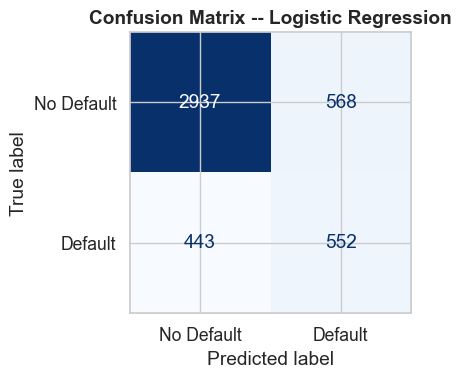

In [21]:
# Logistic Regression (baseline model)
# Why this model?
# - simple & interpretable
# - strong baseline for binary classification
# - good starting point before complex models
lr = LogisticRegression(
    class_weight='balanced',     # handles class imbalance
    C=1.0,                       # regularization strength
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

# ----------------------------

# Cross-validation (checks stability)
cv_lr = cross_val_score(
    lr, X_train_p, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc'
)
print(f'CV AUC: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')

# ----------------------------

# Validation evaluation
lr_res = evaluate('Logistic Regression', lr, X_train_p, y_train, X_val_p, y_val)

---
## 5. Results Summary

- Cross-validation AUC: ~0.7706 ± 0.0076
- Validation AUC: ~0.7668
- Accuracy: 0.7753
- Weighted F1-score: 0.7799
- Recall (Default class): 0.5548
- Precision (Default class): 0.49
# Overall Insight:
-The model performs consistently across CV and validation sets,

-indicating good generalization.


---
## 6. Logistic Regression Summary
Logistic Regression was used as a baseline classifier for credit default prediction.

The model achieves moderate predictive power with an AUC around 0.77,
showing it can reasonably distinguish between defaulters and non-defaulters.

Although overall accuracy appears high (~78%), this is influenced by class imbalance,
so evaluation focuses more on recall and AUC.

The recall of ~0.55 for defaulters indicates the model correctly identifies
more than half of actual risky clients, which is important in credit risk scenarios
where missing a defaulter is more costly than a false alarm.

# Conclusion:
Logistic Regression provides a strong, interpretable baseline but is limited
in capturing nonlinear relationships in customer behavior.
